In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

In [16]:
def conv2d(
    input_volume,
    filters,
    biases=None,
    stride=1,
    padding=0,
):
    """
    input_volume: (height, width, input_channels)
    filters:      (number_of_filters, filter_height, filter_width, input_channels)
    biases:       (number_of_filters,)
    """

    input_volume = np.asarray(input_volume, dtype=float)
    filters = np.asarray(filters, dtype=float)

    if isinstance(stride, int):
        stride_h = stride_w = stride
    else:
        stride_h, stride_w = stride

    if isinstance(padding, int):
        pad_h = pad_w = padding
    else:
        pad_h, pad_w = padding

    input_h, input_w, input_channels = input_volume.shape

    (
        number_of_filters,
        filter_h,
        filter_w,
        filter_channels,
    ) = filters.shape

    if input_channels != filter_channels:
        raise ValueError(
            "The number of input channels must match "
            "the number of filter channels."
        )

    if biases is None:
        biases = np.zeros(number_of_filters)

    biases = np.asarray(biases, dtype=float)

    padded_input = np.pad(
        input_volume,
        (
            (pad_h, pad_h),
            (pad_w, pad_w),
            (0, 0),
        ),
        mode="constant",
    )

    padded_h, padded_w, _ = padded_input.shape

    output_h = ((padded_h - filter_h) // stride_h) + 1
    output_w = ((padded_w - filter_w) // stride_w) + 1

    output = np.zeros(
        (output_h, output_w, number_of_filters),
        dtype=float,
    )

    for output_y in range(output_h):
        for output_x in range(output_w):
            input_y = output_y * stride_h
            input_x = output_x * stride_w

            patch = padded_input[
                input_y:input_y + filter_h,
                input_x:input_x + filter_w,
                :,
            ]

            for filter_index in range(number_of_filters):
                output[output_y, output_x, filter_index] = (
                    np.sum(patch * filters[filter_index])
                    + biases[filter_index]
                )

    return output, padded_input

<h3>3-channel input and two filters</h3>

In [20]:
input_volume = np.array(
    [
        # Channel 0
        [
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 2, 0],
            [0, 1, 0, 2, 0, 1, 0],
            [0, 1, 0, 2, 2, 0, 0],
            [0, 2, 0, 0, 2, 0, 0],
            [0, 2, 1, 2, 2, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ],

        # Channel 1
        [
            [0, 0, 0, 0, 0, 0, 0],
            [0, 2, 1, 2, 1, 1, 0],
            [0, 2, 1, 2, 0, 1, 0],
            [0, 0, 2, 1, 0, 1, 0],
            [0, 1, 2, 2, 2, 2, 0],
            [0, 0, 1, 2, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ],

        # Channel 2
        [
            [0, 0, 0, 0, 0, 0, 0],
            [0, 2, 1, 1, 2, 0, 0],
            [0, 1, 0, 0, 1, 0, 0],
            [0, 0, 1, 0, 0, 0, 0],
            [0, 1, 0, 2, 1, 0, 0],
            [0, 2, 2, 1, 1, 1, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ],
    ],
    dtype=float,
)

# Convert from:
# (channels, height, width)
#
# to:
# (height, width, channels)

input_volume = np.moveaxis(input_volume, 0, -1)

print("Input shape:", input_volume.shape)
# (7, 7, 3)

Input shape: (7, 7, 3)


In [21]:
filter_0 = np.array(
    [
        # Channel 0
        [
            [-1, 0, 1],
            [0, 0, 1],
            [1, -1, 1],
        ],

        # Channel 1
        [
            [-1, 0, 1],
            [1, -1, 1],
            [0, 1, 0],
        ],

        # Channel 2
        [
            [-1, 1, 1],
            [1, 1, 0],
            [0, -1, 0],
        ],
    ],
    dtype=float,
)

filter_1 = np.array(
    [
        # Channel 0
        [
            [0, 1, -1],
            [0, -1, 0],
            [0, -1, 1],
        ],

        # Channel 1
        [
            [-1, 0, 0],
            [1, -1, 0],
            [1, -1, 0],
        ],

        # Channel 2
        [
            [-1, 1, -1],
            [0, -1, -1],
            [1, 0, 0],
        ],
    ],
    dtype=float,
)

<h4><b>The filters currently have shape (channels, height, width), so move the channel axis to the end:</b></h4>

In [22]:
# Convert from:
# (channels, filter_height, filter_width)
#
# to:
# (filter_height, filter_width, channels)

filter_0 = np.moveaxis(filter_0, 0, -1)
filter_1 = np.moveaxis(filter_1, 0, -1)

# Shape:
# (number_of_filters, filter_height, filter_width, channels)

filters = np.stack([filter_0, filter_1])

biases = np.array([1, 0], dtype=float)

print("Filters shape:", filters.shape)
# (2, 3, 3, 3)

Filters shape: (2, 3, 3, 3)


In [23]:
def show_matrix(
    axis,
    matrix,
    title,
    cmap="viridis",
    vmin=None,
    vmax=None,
):
    image = axis.imshow(
        matrix,
        cmap=cmap,
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )

    axis.set_title(title)

    axis.set_xticks(np.arange(matrix.shape[1]))
    axis.set_yticks(np.arange(matrix.shape[0]))

    axis.set_xticks(
        np.arange(-0.5, matrix.shape[1], 1),
        minor=True,
    )
    axis.set_yticks(
        np.arange(-0.5, matrix.shape[0], 1),
        minor=True,
    )

    axis.grid(
        which="minor",
        linewidth=1,
    )

    axis.tick_params(which="minor", bottom=False, left=False)

    normalizer = Normalize(
        vmin=np.min(matrix) if vmin is None else vmin,
        vmax=np.max(matrix) if vmax is None else vmax,
    )

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix[row, column]

            normalized_value = normalizer(value)

            text_color = (
                "white"
                if normalized_value < 0.3 or normalized_value > 0.75
                else "black"
            )

            axis.text(
                column,
                row,
                f"{value:g}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=9,
            )

    return image

In [24]:
def visualize_convolution(
    input_volume,
    filters,
    biases,
    output,
    padded_input,
    padding,
    stride,
):
    number_of_filters = filters.shape[0]
    input_channels = input_volume.shape[2]

    # One row for input, then one row for each filter.
    rows = number_of_filters + 1

    # Channel images + one combined/output image.
    columns = input_channels + 1

    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(4 * columns, 3.8 * rows),
        constrained_layout=True,
    )

    if rows == 1:
        axes = axes[np.newaxis, :]

    # --------------------------------------------------
    # Input row
    # --------------------------------------------------

    input_min = np.min(input_volume)
    input_max = np.max(input_volume)

    for channel in range(input_channels):
        image = show_matrix(
            axes[0, channel],
            input_volume[:, :, channel],
            title=f"Input channel {channel}",
            cmap="Blues",
            vmin=input_min,
            vmax=input_max,
        )

        figure.colorbar(
            image,
            ax=axes[0, channel],
            fraction=0.046,
        )

    # Display the padded input as a channel-combined grayscale image.
    combined_input = np.mean(padded_input, axis=2)

    image = show_matrix(
        axes[0, -1],
        combined_input,
        title=f"Padded input\npadding={padding}, stride={stride}",
        cmap="Blues",
    )

    figure.colorbar(
        image,
        ax=axes[0, -1],
        fraction=0.046,
    )

    # --------------------------------------------------
    # Filter and output rows
    # --------------------------------------------------

    filter_min = np.min(filters)
    filter_max = np.max(filters)

    output_min = np.min(output)
    output_max = np.max(output)

    for filter_index in range(number_of_filters):
        row = filter_index + 1

        for channel in range(input_channels):
            image = show_matrix(
                axes[row, channel],
                filters[filter_index, :, :, channel],
                title=(
                    f"Filter {filter_index}, "
                    f"channel {channel}"
                ),
                cmap="RdBu_r",
                vmin=filter_min,
                vmax=filter_max,
            )

            figure.colorbar(
                image,
                ax=axes[row, channel],
                fraction=0.046,
            )

        image = show_matrix(
            axes[row, -1],
            output[:, :, filter_index],
            title=(
                f"Output feature map {filter_index}\n"
                f"bias={biases[filter_index]:g}"
            ),
            cmap="Greens",
            vmin=output_min,
            vmax=output_max,
        )

        figure.colorbar(
            image,
            ax=axes[row, -1],
            fraction=0.046,
        )

    figure.suptitle(
        "Multi-channel convolution visualization",
        fontsize=16,
    )

    plt.show()

Output shape: (5, 5, 2)


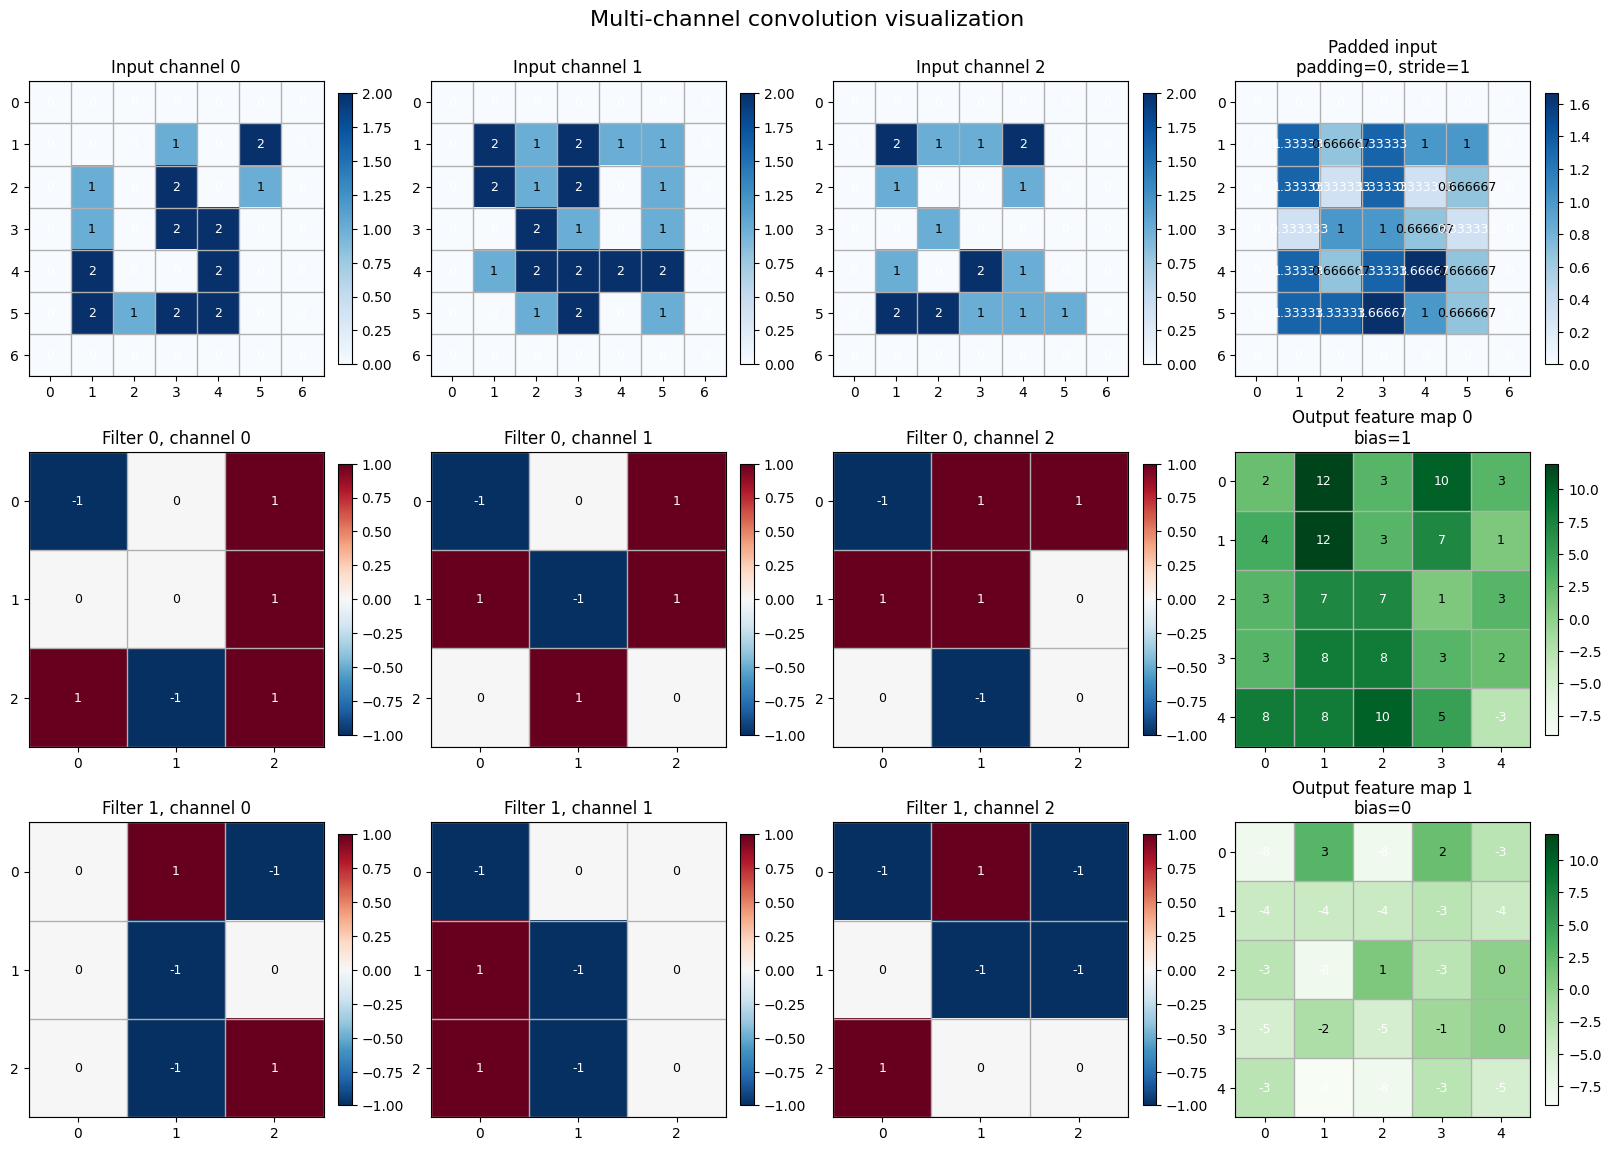

In [25]:
padding = 0
stride = 1

output, padded_input = conv2d(
    input_volume=input_volume,
    filters=filters,
    biases=biases,
    padding=padding,
    stride=stride,
)

print("Output shape:", output.shape)

visualize_convolution(
    input_volume=input_volume,
    filters=filters,
    biases=biases,
    output=output,
    padded_input=padded_input,
    padding=padding,
    stride=stride,
)

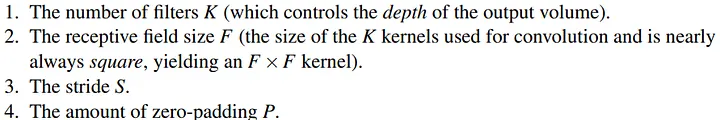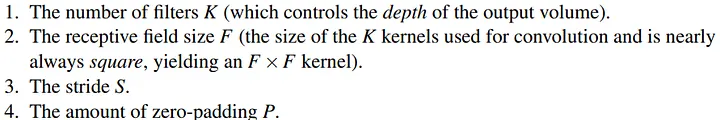

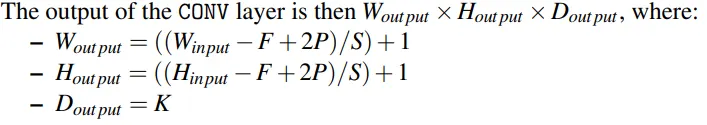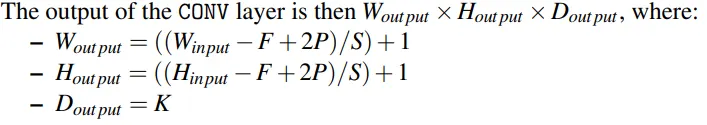